# 6.5 ガウス過程分類 (Gaussian Processes for Classification)

本ノートブックでは、二値分類問題に対してガウス過程を拡張する**ガウス過程分類 (Gaussian Process Classification: GPC)** を学びます。
非線形潜在関数 $a(\mathbf{x})$ に対するガウス過程事前分布、ベルヌーイ尤度による事後分布の解析的非ガウス性、ラプラス近似を用いた Newton-Raphson 反復法による最頻値 $\mathbf{a}_{\mathrm{MAP}}$ の探索（**PRML 式 6.83**）、潜在変数予測分布の閉形式平均・分散、およびプロビット近似畳み込みによる決定境界と軟化確率の視覚化（**PRML Figure 6.11, 6.12**）を完全実装します。

## 6.5 ガウス過程分類の数理とラプラス近似

### 1. 潜在変数モデルと尤度関数
二値分類問題 $t \in \{0, 1\}$ において、目標値の条件付き確率は潜在関数 $a(\mathbf{x})$ をロジスティックシグモイド関数 $\sigma(a) = \frac{1}{1 + e^{-a}}$ で変換したものと仮定します：
$$ p(t = 1 | a) = \sigma(a) $$
潜在関数ベクトル $\mathbf{a}_N = (a_1, \dots, a_N)^T$ に対して、共分散行列 $\mathbf{K}$ を持つガウス過程事前分布を与えます：
$$ p(\mathbf{a}_N) = \mathcal{N}(\mathbf{a}_N | \mathbf{0}, \mathbf{K}) $$
独立同分布な観測データ $\mathbf{t}_N = (t_1, \dots, t_N)^T$ の尤度は：
$$ p(\mathbf{t}_N | \mathbf{a}_N) = \prod_{n=1}^N \sigma(a_n)^{t_n} (1 - \sigma(a_n))^{1 - t_n} $$

### 2. ラプラス近似と Newton-Raphson 更新 (PRML 式 6.80 - 6.83)
事後分布 $p(\mathbf{a}_N | \mathbf{t}_N) \propto p(\mathbf{a}_N) p(\mathbf{t}_N | \mathbf{a}_N)$ はシグモイド関数の積を含むため厳密にはガウス分布になりません。
そこで最頻値 $\mathbf{a}_{\mathrm{MAP}}$ における2次のテイラー展開（ラプラス近似）を行います：
$$ \Psi(\mathbf{a}) \equiv \ln p(\mathbf{a}|\mathbf{t}) = -\frac{1}{2}\mathbf{a}^T \mathbf{K}^{-1}\mathbf{a} + \sum_{n=1}^N [t_n \ln \sigma(a_n) + (1 - t_n)\ln(1 - \sigma(a_n))] + \text{const} $$
勾配およびヘッセ行列は：
$$ \nabla \Psi(\mathbf{a}) = \mathbf{t} - \boldsymbol{\sigma}(\mathbf{a}) - \mathbf{K}^{-1}\mathbf{a} $$
$$ \nabla \nabla \Psi(\mathbf{a}) = -\mathbf{W} - \mathbf{K}^{-1} $$
ここで $\mathbf{W}$ は対角要素が $W_{nn} = \sigma(a_n)(1 - \sigma(a_n))$ の対角行列です。
最頻値を求める Newton-Raphson 更新式は：
$$ \mathbf{a}^{\mathrm{new}} = (\mathbf{K}^{-1} + \mathbf{W})^{-1} (\mathbf{t} - \boldsymbol{\sigma}(\mathbf{a}) + \mathbf{W}\mathbf{a}) = \mathbf{K}(\mathbf{I} + \mathbf{W}\mathbf{K})^{-1} (\mathbf{t} - \boldsymbol{\sigma}(\mathbf{a}) + \mathbf{W}\mathbf{a}) $$

### 3. 予測分布とプロビット近似畳み込み (PRML Figure 6.11 & 6.12)
テスト点 $\mathbf{x}_*$ における潜在関数 $a_*$ の事後分布は、ラプラス近似の下でガウス分布 $\mathcal{N}(\mu_{a_*}, \sigma_{a_*}^2)$ となります：
$$ \mu_{a_*} = \mathbf{k}_*^T (\mathbf{t} - \boldsymbol{\sigma}(\mathbf{a}_{\mathrm{MAP}})) $$
$$ \sigma_{a_*}^2 = c_* - \mathbf{k}_*^T (\mathbf{K} + \mathbf{W}^{-1})^{-1} \mathbf{k}_* $$
事後クラス確率 $p(t_* = 1 | \mathbf{t}) = \int \sigma(a_*) \mathcal{N}(a_* | \mu_{a_*}, \sigma_{a_*}^2) da_*$ は、プロビット近似を用いて解析的に求まります：
$$ p(t_* = 1 | \mathbf{t}) \simeq \sigma\left( \kappa(\sigma_{a_*}^2) \mu_{a_*} \right), \quad \kappa(\sigma^2) = \left( 1 + \frac{\pi}{8}\sigma^2 \right)^{-1/2} $$

Plot saved to: result/fig6_12_gp_classification.png


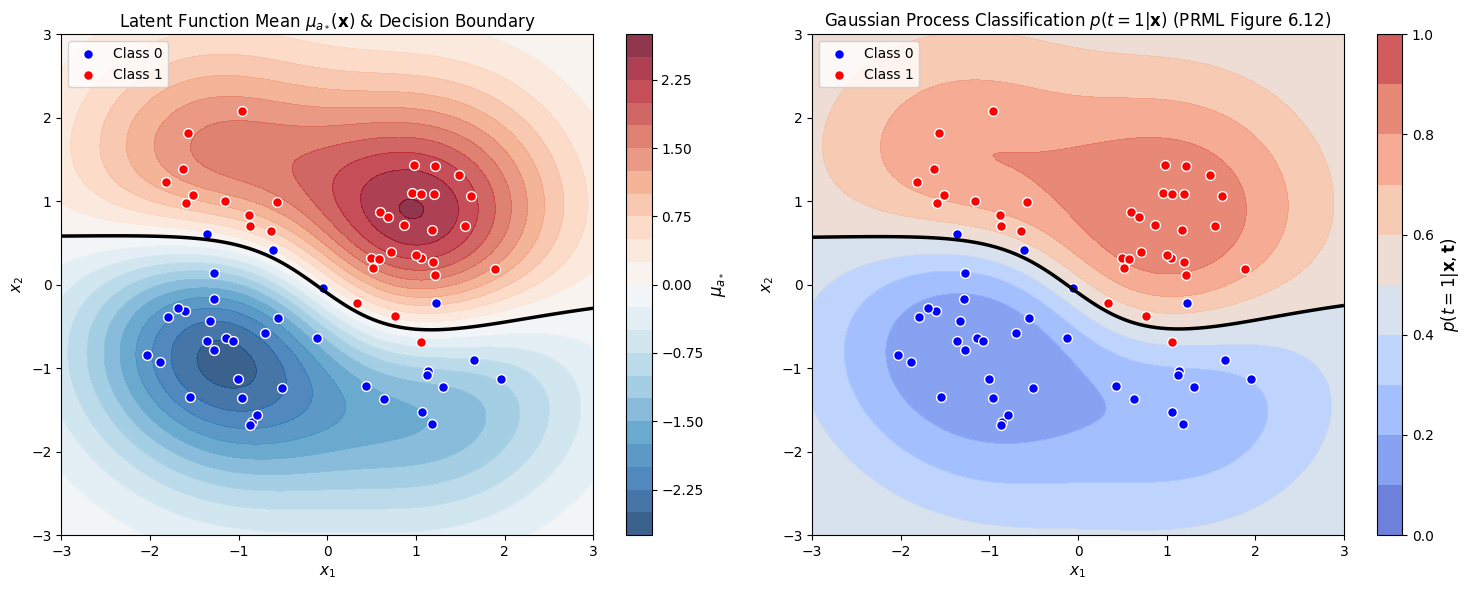

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.kernel_utils import GaussianProcessClassifier, rbf_kernel
setup_style()

# PRML Figure 6.11 & 6.12 の完全再現: 合成2次元非線形分類データ
np.random.seed(42)
N1, N2 = 25, 25
X1 = np.random.randn(N1, 2) * 0.6 + np.array([-1.0, -0.5])
X2 = np.random.randn(N2, 2) * 0.6 + np.array([1.0, 0.5])
# 少し非線形な重なり
X1 = np.vstack([X1, np.random.randn(10, 2) * 0.4 + np.array([1.2, -1.2])])
X2 = np.vstack([X2, np.random.randn(10, 2) * 0.4 + np.array([-1.2, 1.2])])

X_train = np.vstack([X1, X2])
t_train = np.array([0]*len(X1) + [1]*len(X2))

# ガウス過程分類器の学習 (RBF カーネル)
gpc = GaussianProcessClassifier(kernel=rbf_kernel, length_scale=1.0, variance=1.0)
gpc.fit(X_train, t_train)

# 2次元評価グリッド
x_range = np.linspace(-3.0, 3.0, 100)
y_range = np.linspace(-3.0, 3.0, 100)
GX, GY = np.meshgrid(x_range, y_range)
X_test_grid = np.column_stack([GX.ravel(), GY.ravel()])

# 予測確率の評価
prob_grid = gpc.predict_proba(X_test_grid).reshape(100, 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) 潜在関数の平均 mu_a の等高線
k_star = gpc.kernel(X_test_grid, gpc.X_train, length_scale=1.0, variance=1.0)
mu_a_grid = (k_star @ (gpc.t_train - gpc.predict_proba(gpc.X_train))).reshape(100, 100)
c1 = axes[0].contourf(GX, GY, mu_a_grid, levels=20, cmap='RdBu_r', alpha=0.8)
axes[0].contour(GX, GY, mu_a_grid, levels=[0.0], colors='k', linewidths=2.5)
axes[0].scatter(X1[:, 0], X1[:, 1], c='blue', edgecolors='white', s=50, label='Class 0')
axes[0].scatter(X2[:, 0], X2[:, 1], c='red', edgecolors='white', s=50, label='Class 1')
axes[0].set_title('Latent Function Mean $\mu_{a_*}(\mathbf{x})$ & Decision Boundary', fontsize=12)
axes[0].set_xlabel('$x_1$', fontsize=11); axes[0].set_ylabel('$x_2$', fontsize=11)
axes[0].legend(loc='upper left', fontsize=10)
fig.colorbar(c1, ax=axes[0], label='$\mu_{a_*}$')

# (b) プロビット近似による予測事後確率 p(t=1|x) (PRML Figure 6.12)
c2 = axes[1].contourf(GX, GY, prob_grid, levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.8)
axes[1].contour(GX, GY, prob_grid, levels=[0.5], colors='k', linewidths=2.5)
axes[1].scatter(X1[:, 0], X1[:, 1], c='blue', edgecolors='white', s=50, label='Class 0')
axes[1].scatter(X2[:, 0], X2[:, 1], c='red', edgecolors='white', s=50, label='Class 1')
axes[1].set_title('Gaussian Process Classification $p(t=1|\mathbf{x})$ (PRML Figure 6.12)', fontsize=12)
axes[1].set_xlabel('$x_1$', fontsize=11); axes[1].set_ylabel('$x_2$', fontsize=11)
axes[1].legend(loc='upper left', fontsize=10)
fig.colorbar(c2, ax=axes[1], label='$p(t=1|\mathbf{x}, \mathbf{t})$')

plt.tight_layout()
save_plot(fig, 'result', 'fig6_12_gp_classification.png')
plt.show()